--------------------------

## Anode & Cathode Currents as a Function of Time in Comparison to Target Current (From C-Rate)
#### The example code below extracts and plots the currents from a full-cell simulation.

- Ensure the simulation output file (e.g., `full_cell_output.txt`) contains lines with `Anode current = ...` and `Cathode current = ...` values in a consistent format.
- Update the file path on Line #7 to point to the desired simulation output file.
- Modify Line #15 if extracting different variables or changing the parsing format.
- Change Line #27 to remove earlier timesteps.
- Run the script to generate a plot of cathode and anode currents versus time.

<p style="color:red;"><strong> Warning:</strong> Check that <code>full_cell_output.txt</code> only contains data from one simulation run. Reusing the file without clearing it can result in overlapping plot data.</p>

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/half_cell_output_charge_01.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
        # r"timestep:\s*(\d+).*?Anode current\s*=\s*([-eE0-9.]+),\s*Cathode current\s*=\s*([-eE0-9.]+),.*?Target Current\s*=\s*([-eE0-9.]+)"
        r"timestep:\s*(\d+).*?current\s*=\s*([-eE0-9.]+),.*?target current\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        # anode = abs(float(match.group(2)))  # absolute value
        cathode = float(match.group(2))
        target = float(match.group(3))
        # data.append((timestep, anode, cathode, target))
        data.append((timestep, cathode, target))


start_timestep = 1000  # change this to a different timestep if needed

# --- Step 3: Convert to DataFrame ---
# df = pd.DataFrame(data, columns=["Timestep", "Anode", "Cathode", "Target"])
df = pd.DataFrame(data, columns=["Timestep", "Cathode", "Target"])

df = df[df["Timestep"] >= start_timestep]

df = df[df["Timestep"] != 0] # Remove timestep 0
# Remove all salt conservation timesteps (500, 1000, 1500, ...)
# df = df[df["Timestep"] % 500 != 0]

# --- Step 4: Plot ---
plt.figure(figsize=(10,6))
# plt.plot(df["Timestep"], df["Anode"], label="Anode current", linewidth=2)
plt.plot(df["Timestep"], df["Cathode"], label="Cathode current", linewidth=2)
plt.plot(df["Timestep"], df["Target"], '--', label="Target current", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Current")
plt.title("Full-Cell Currents vs Time Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--------------------------

## Cell Voltage Plots as a Function of Lithium Concentration
#### The example code below extracts and plots the cathode cell voltage from a full-cell simulation.

- Ensure the simulation output file (e.g., `full_cell_output.txt`) contains lines with `XfrC = ...` and `VCell = ...` values in a consistent format.
- Update the file path on Line #7 to point to the desired simulation output file.
- Modify Line #15 if extracting different variables or changing the parsing format.
- Run the script to generate a plot of cell voltage (`VCell`) versus cathode lithium fraction (`XfrC`).

<p style="color:red;"><strong> Warning:</strong> Check that <code>full_cell_output.txt</code> only contains data from one simulation run. Reusing the file without clearing it can result in overlapping plot data.</p>

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
file_path = "../bin/half_cell_output_charge_01.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse timestep, Xfr, and VCell ---
data = []
pattern = re.compile(
    r"timestep:\s*(\d+).*?Xfr\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        XfrC = float(match.group(2))
        vcell = abs(float(match.group(3)))  # absolute value
        data.append((timestep, XfrC, vcell))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["timestep", "Xfr", "VCell"])

# --- Step 4: Remove timesteps divisible by 500 ---
# df = df[df["timestep"] % 500 != 0]

# Optional: remove timestep 0 too
# df = df[df["timestep"] != 0]

# --- Step 5: Plot ---
plt.figure(figsize=(10,6))
plt.plot(df["Xfr"], df["VCell"], label="VCell", linewidth=2)

plt.xlabel("Xfr")
plt.ylabel("Cell Voltage")
plt.title("VCell vs Xfr")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Helper function to parse a file ---
def parse_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    data = []
    pattern = re.compile(
        r"timestep:\s*(\d+).*?Xfr\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
    )

    for line in lines:
        match = pattern.search(line)
        if match:
            timestep = int(match.group(1))
            Xfr = float(match.group(2))
            vcell = abs(float(match.group(3)))  # keep consistent with your original
            data.append((timestep, Xfr, vcell))

    df = pd.DataFrame(data, columns=["timestep", "Xfr", "VCell"])

    # Optional filtering (same as before)
    # df = df[df["timestep"] % 500 != 0]
    # df = df[df["timestep"] != 0]

    return df


# --- Load both files ---
df_charge = parse_file("../bin/half_cell_output_discharge.txt")
df_discharge = parse_file("../bin/half_cell_output_charge.txt")

# --- Plot ---
plt.figure(figsize=(10,6))

plt.plot(df_charge["Xfr"], df_charge["VCell"], 
         label="Charge", linewidth=2)

plt.plot(df_discharge["Xfr"], df_discharge["VCell"], 
         label="Discharge", linewidth=2)

plt.xlabel("Xfr")
plt.ylabel("Cell Voltage")
plt.title("VCell vs Xfr (Charge vs Discharge)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Length of x_ocv: 101
Length of y_ocv: 101


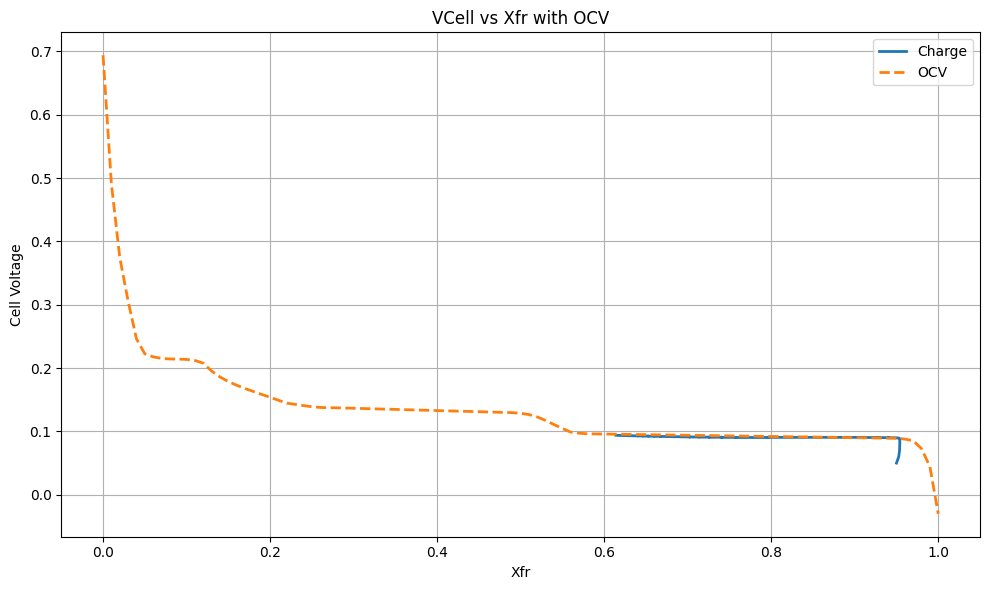

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Helper function to parse BESFEM output files ---
def parse_half_cell_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    data = []
    pattern = re.compile(
        r"timestep:\s*(\d+).*?Xfr\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
    )

    for line in lines:
        match = pattern.search(line)
        if match:
            timestep = int(match.group(1))
            Xfr = float(match.group(2))
            VCell = abs(float(match.group(3))) 
            data.append((timestep, Xfr, VCell))

    df = pd.DataFrame(data, columns=["timestep", "Xfr", "VCell"])
    return df


# --- Load simulation data ---
df_charge = parse_half_cell_file("../bin/half_cell_output_charge_01.txt")
df_discharge = parse_half_cell_file("../bin/half_cell_output_discharge_01.txt")

# Optional filtering
# df_charge = df_charge[df_charge["timestep"] % 500 != 0]
# df_discharge = df_discharge[df_discharge["timestep"] % 500 != 0]

# # Optional sorting by Xfr
# df_charge = df_charge.sort_values("Xfr")
# df_discharge = df_discharge.sort_values("Xfr")


# --- Load OCV data ---
x_ocv = np.loadtxt("../inputs/C_Li_X_101.txt")
y_ocv = np.loadtxt("../inputs/C_Li_O3_101.txt")

# If y_ocv is read as a 2D column vector, flatten it
y_ocv = np.ravel(y_ocv)


# --- Check lengths match ---
print("Length of x_ocv:", len(x_ocv))
print("Length of y_ocv:", len(y_ocv))


# --- Plot all curves together ---
plt.figure(figsize=(10, 6))

plt.plot(df_charge["Xfr"], df_charge["VCell"],
         label="Charge", linewidth=2)

plt.plot(df_discharge["Xfr"], df_discharge["VCell"],
         label="Discharge", linewidth=2)

plt.plot(x_ocv, y_ocv,
         label="OCV", linewidth=2, linestyle="--")

plt.xlabel("Xfr")
plt.ylabel("Cell Voltage")
plt.title("VCell vs Xfr with OCV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()